#**TRABAJO INTEGRADOR FINAL**  

#**MODULO:  MODELADO DE SISTEMAS DE IA APLICADA**

#**Grupo 2**

#**Integrantes**:

* Alejandro, Jessica Belén

* Durán, Alicia

* Gimenez Soria, Melina Jaqueline

* Guerrero, Daniela Viviana

* Vallejo Guerrero, Nicolás Ezequiel

# ✋ **<font color='littleblue'>Prototipo ML Clasificación de Tickets de Soporte**

#1.**<font color='orange'>Contexto**

El proyecto nace de una necesidad crítica en el departamento de atención al cliente que es *la saturación provocada por la gestión manual de correos y consultas diarias*. Actualmente, el proceso depende de operadores que deben leer, categorizar y derivar cada mensaje uno por uno, lo que no solo consume tiempo valioso, sino que impacta directamente en la satisfacción de los clientes.

#2.**<font color='orange'>Objetivo**

El objetivo central de nuestro proyecto es desarrollar un modelo capaz de automatizar la categorización y derivación de las consultas, reemplazando el proceso manual.


#3.**<font color='orange'>Propuesta de Solución**

Para resolver esta problemática, se propuso un modelo de aprendizaje supervisado enfocado en la **Clasificación**.

Se eligio el algoritmo **Random Forest (Bosque Aleatorio)** ya que es reconocido por su robustez al manejar grandes volúmenes de datos y su capacidad para procesar simultáneamente texto, variables numéricas y categóricas. Al utilizar un conjunto de árboles de decisión, el modelo reduce el riesgo de sobreajuste y garantiza una mayor precisión al identificar patrones en los correos electrónicos, facilitando la predicción de variables clave como el departamento de destino y el tipo de ticket.


#4.**<font color='orange'>Analisis del Dataset**

##4.1. Importación de Librerias

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

##4.2. Lectura del Dataset



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Carga del dataset
file_name = "/content/drive/MyDrive/data/aa_dataset-tickets-multi-lang-5-2-50-version.csv"
df = pd.read_csv(file_name)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


* Se identifican 16 variables; 1 variable numérica `version` y el resto variables categóricas.

* Se observan datos faltantes en las variables: `subject`, `answer`, `tag_2`, `tag_3`, `tag_4`, `tag_5`, `tag_6`, `tag_7`, `tag_8`.


* Diccionario de Datos:

Fuentes de Datos: Kaggle

*<font color='orange'> `subject`</font>: Asunto del correo electrónico del cliente

*<font color='orange'> `body`</font>: Texto del correo electrónico del cliente

*<font color='orange'> `answer`</font>: Respuesta proporcionada por el operador

*<font color='orange'> `type`</font>: Tipo de tickets seleccionado por el operador

*<font color='orange'> `queue`</font>: Especifica el departamente al que se enruta el correo electrónico

*<font color='orange'> `priority`</font>: Indica la urgencia o importancia del problema

*<font color='orange'> `language`</font>: Idioma en el que está escrito el correo electrónico

*<font color='orange'> `tag`</font>: Etiquetas/categorías asignadas al correo electrónico



In [4]:
# Muestra las primeras 5 filas
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [5]:
# Muestra las últimas 5 filas
df.tail()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
28582,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,high,en,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
28583,Datensperrung in der Kundschaftsbetreuung,"Es gab einen Datensperrungsunfall, bei dem ung...",Ich kann Ihnen bei dem Datensperrungsunfall he...,Incident,Product Support,high,de,400,Security,IT,Tech Support,Bug,NaN,NaN,NaN,NaN
28584,Problem mit der Videokonferenz-Software heute,Wichtigere Sitzungen wurden unterbrochen durch...,"Sehr geehrte/r [Name], leider wurde das Proble...",Incident,Human Resources,low,de,400,Bug,Performance,Network,IT,Tech Support,NaN,NaN,NaN
28585,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,high,en,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
28586,Inquiry About Project Management Features,Looking for detailed information on the projec...,"Dear [Name], thank you for your email regardin...",Request,Technical Support,low,en,400,Feature,Documentation,Feedback,IT,NaN,NaN,NaN,NaN


Para el propósito del Modelo como el dataset tiene correos electrónicos en alemán e inglés. Se aplicará un filtro para usar únicamente los correos en inglés.

In [6]:
# Filtra exclusivamente los correos en inglés
df_en = df[df['language'].str.lower() == 'en'].copy()

print(f"Total de registros originales: {len(df)}")
print(f"Total de registros (Solo Inglés): {len(df_en)}\n")

Total de registros originales: 28587
Total de registros (Solo Inglés): 16338



Guardamos el nuevo dataframe como `.csv` en `My Drive` para evitar que el archivo se guardara en el almacenamiento temporal de la sesión de Colab.

In [7]:
# Define la ruta
ruta_guardado = '/content/drive/MyDrive/data/emails_ingles.csv'

# Guarda el DataFrame como CSV
df_en.to_csv(ruta_guardado, index=False, encoding='utf-8')

print(f"Archivo guardado exitosamente en: {ruta_guardado}")

Archivo guardado exitosamente en: /content/drive/MyDrive/data/emails_ingles.csv


#5.**<font color='orange'>Análisis Exploratorio de Datos**

In [8]:
# Estadística descriptiva
df_en.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject,13731,13731,Inquiry About Project Management Features,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,16338,16338,Looking for detailed information on the projec...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,16335,16335,"Dear [Name], thank you for your email regardin...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,16338,4,Incident,6571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
queue,16338,10,Technical Support,4737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,16338,3,medium,6618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,16338,1,en,16338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
version,16338.0,NaN,NaN,NaN,274.359958,167.184913,51.0,52.0,400.0,400.0,400.0
tag_1,16338,81,Security,3333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tag_2,16332,197,Performance,3357,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A continuación, se hace un pequeño análisis para visualizar si existen valores nulos en el nuevo dataframe `df_en`.

In [9]:
# Revisión de Valores Nulos en nuestro nuevo df
print("--- Valores Nulos por columna ---")
nulos = df_en.isnull().sum()
print(nulos[nulos > 0])
print("-" * 35)

--- Valores Nulos por columna ---
subject     2607
answer         3
tag_2          6
tag_3         69
tag_4       1711
tag_5       7922
tag_6      12968
tag_7      15204
tag_8      16057
dtype: int64
-----------------------------------


Elegimos analizar las variables <font color='red'> `priority`</font>, <font color='red'> `type` </font> y <font color='red'>`queue` </font> como <font color='red'> Variables Objetivos </font> porque agrupan a los correos y las que más nos interesa mantener balanceadas para hacer buenos análisis o entrenar nuestro modelos de IA.

In [10]:
# Calcula la frecuencia absoluta de cada nivel de prioridad en el dataset
df_en['priority'].value_counts()

,count
priority,
medium,6618
high,6346
low,3374


La variable categórica `priority` (prioridad) muestra la distribución de frecuencias de los registros en el conjunto de datos.
Las prioridades `medium` (media): 6618 y `high` (alta):6346 presentando un volumen de casos muy equilibrado entre ambas.
Por el contrario, la prioridad `low` (bajo) es la menos frecuente con solo 3374 registros, lo que indica una clara minoría de casos de baja urgencia.

In [11]:
# Calcula la frecuencia absoluta de cada tipo de ticket en el dataset
df_en['type'].value_counts()

,count
type,
Incident,6571
Request,4665
Problem,3397
Change,1705


La variable categórica `type` (tipo) revela que la gran mayoría de los registros corresponden a "Incidents" (Incidente): 6571, siendo el tipo de ticket más frecuente.
En un segundo nivel de volumen se encuentran los `Requests` (Solicitudes): 4665 y los `Problems` (Problemas): 3397, representando la carga operativa regular.
Finalmente, la categoría `Change` (Cambio): 1705 es la de menor ocurrencia, indicando que las modificaciones al sistema o infraestructura son eventos mucho menos comunes.

In [12]:
# Calcula la frecuencia absoluta de correos asignados a cada departamento
df_en['queue'].value_counts()

,count
queue,
Technical Support,4737
Product Support,3073
Customer Service,2410
IT Support,1942
Billing and Payments,1595
Returns and Exchanges,820
Service Outages and Maintenance,664
Sales and Pre-Sales,513
Human Resources,348


La distribución de la variable `queue` muestra que la mayor parte de la carga operativa se concentra en `Technical Support` (Soporte Técnico): 4737, siendo el área más demandada con diferencia.
En un segundo nivel de volumen se agrupan áreas clave como `Product Support` (Soporte de Producto): 3,073 y `Customer Service` (Servicio al Cliente): 2410, que junto al soporte técnico forman el núcleo principal de atención.
Por el contrario, los departamentos enfocadas en procesos internos o dudas iniciales, como `Human Resources` (Recursos Humanos): 348 y `General Inquiry` (Consulta General): 236, representan la menor cantidad de tickets gestionados.



---



---



Es fundamental saber qué tan largos son los textos de los correos electrónicos para entrenar nuestro modelo.

Los modelos de lenguaje no pueden leer un texto infinito. Tienen un límite de entrada fijo, conocido como longitud máxima de secuencia (por ejemplo, 214, 377 o 533 "tokens" o palabras).

Si no sabemos cuánto miden los correos, no sabremos qué límite configurar al modelo y por lo tanto, clasificará erróneamente.

In [13]:
# Calcula las longitudes y muestra el resumen estadístico al instante
df_en['body'].str.len().describe()

,body
count,16338.000000
mean,367.887379
std,179.885725
min,6.000000
25%,214.000000
50%,377.000000
75%,533.000000
max,1147.000000


La variable `body` (Cuerpo del Texto) abarca 16,338 registros y presenta una extensión promedio de aproximadamente 368 caracteres o palabras.
Su distribución es bastante equilibrada y simétrica, ya que la mediana (377) está muy alineada con la media, ubicando al 50% central de los textos entre las medidas de 214 y 533.
Por otro lado, los casos extremos muestran una amplia variabilidad, yendo desde descripciones sumamente breves (mínimo de 6) hasta contenidos muy extensos y detallados (máximo de 1,147).

# 6.**<font color='orange'>Visualización**

In [14]:
# Configura el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

* *Distribución de los correos electrónicos por* `priority`


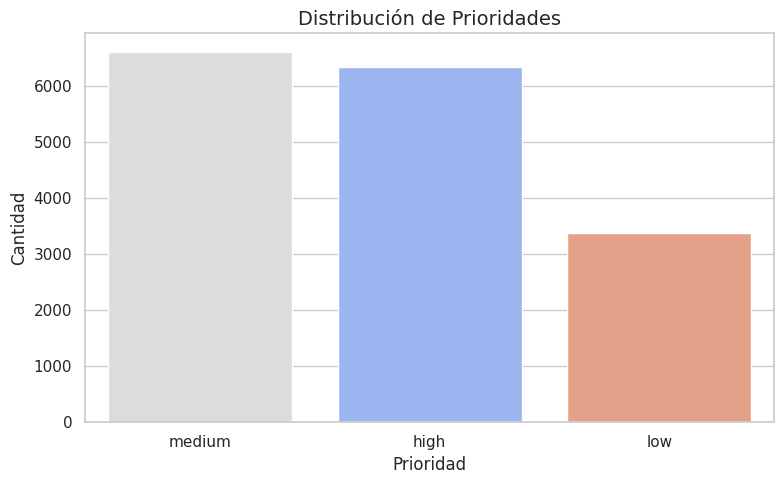

In [15]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_en,
    x='priority',
    order=df_en['priority'].value_counts().index,
    palette='coolwarm',
    hue='priority'
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('Distribución de Prioridades', fontsize=14)
plt.xlabel('Prioridad', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.tight_layout()

plt.show()

* *Distribución de los correos electrónicos por*`type`

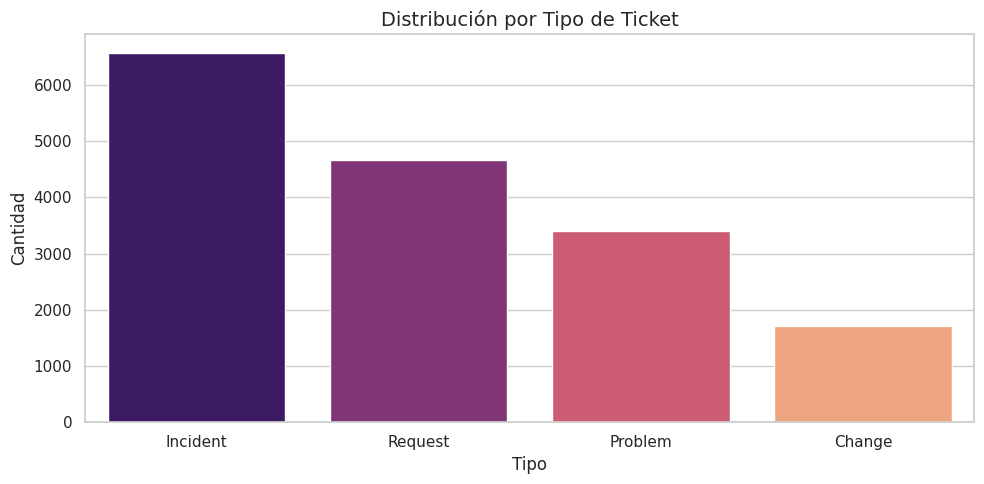

In [16]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df_en,
    x='type',
    order=df_en['type'].value_counts().index,
    palette='magma',
    hue='type'
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('Distribución por Tipo de Ticket', fontsize=14)
plt.xlabel('Tipo', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.tight_layout()

plt.show()

* *Distribución de los correos electrónicos por* `queue`

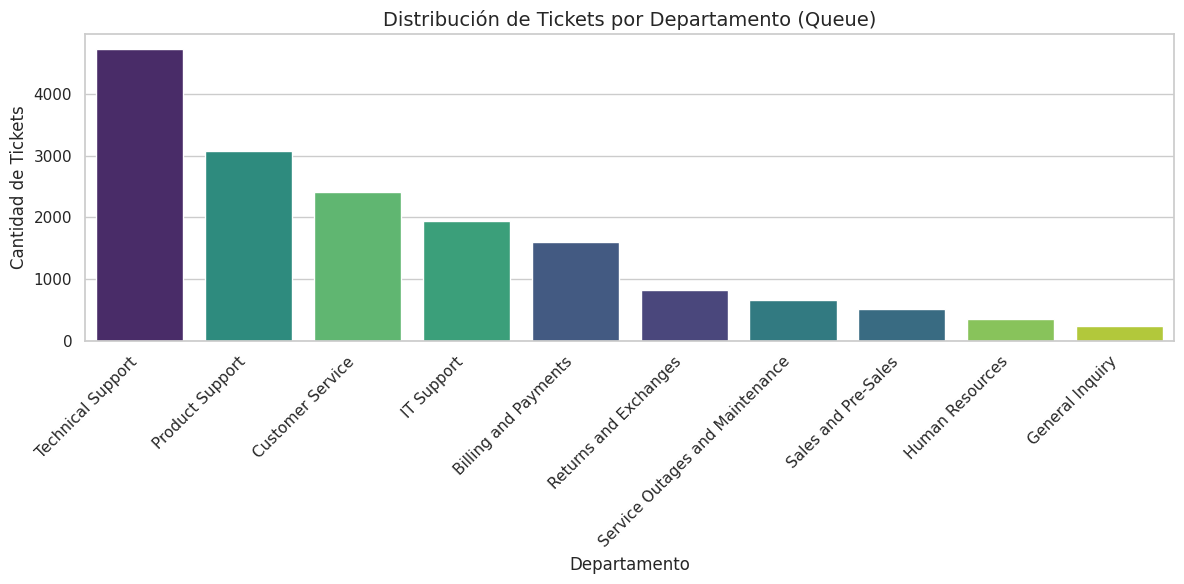

In [17]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_en, x='queue',
    order=df_en['queue'].value_counts().index,
    palette='viridis',
    hue='queue',
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('Distribución de Tickets por Departamento (Queue)', fontsize=14)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Cantidad de Tickets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

* *Distribución de la longitud de los correos electrónicos*

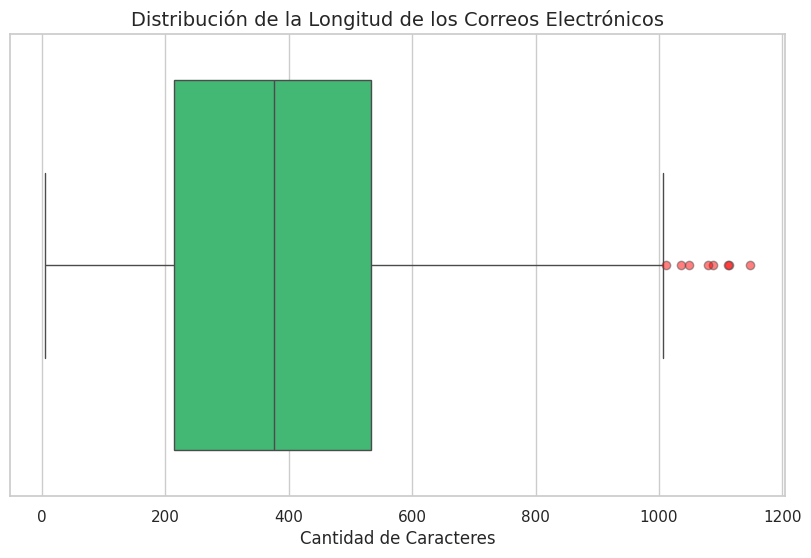

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df_en['body'].str.len(),
    color='#2ECC71', # Color de la caja
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.5}
)

plt.title('Distribución de la Longitud de los Correos Electrónicos', fontsize=14)
plt.xlabel('Cantidad de Caracteres', fontsize=12)

plt.show()

# 7.<font color='orange'>**Preprocesamiento de Datos**

##7.1.Limpieza de Datos

Debido a que se encontraron valores nulos en los datos a utilizar; se aplicará una limpieza en el dataset filtrado, eliminando columnas que no aportan valor y rellenando los datos nulos con espacio en blanco o guión. Además, se concatena la variable `subject` y la variable `body` con el fin de evitar omitir las palabras de peso si estás se encuentran en el asunto del correo electrónico (Subject).

In [19]:
# 1. Hace una nueva copia para no alterar el df_en
df_resultado = df_en.copy()

# 2. Elimina las columnas que no aportan valor
columnas_basura = ['tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'version']
# Esta línea verifica cuáles de esas columnas existen y las borra
columnas_a_borrar = [col for col in columnas_basura if col in df_resultado.columns]
df_resultado = df_resultado.drop(columns=columnas_a_borrar)

# 3. Previene el problema de los valores nulos (NaN)
# En Pandas, si concatenas un texto con un valor nulo, el resultado se vuelve nulo.
# Rellenamos los vacíos para evitar perder información.
df_resultado['subject'] = df_resultado['subject'].fillna('No Subject')
df_resultado['body'] = df_resultado['body'].fillna('')

# 4. Crea la nueva columna combinada
# Usamos un guión " - " (o podría ser un espacio " ") para que la última palabra
# del asunto no se pegue con la primera palabra del cuerpo.
df_resultado['texto_completo'] = df_resultado['subject'] + " - " + df_resultado['body']

# 5. Define ruta y guarda (Ahora tu CSV estará mucho más limpio y pesará menos)
ruta_guardado = '/content/drive/MyDrive/data/analisis_emails_ingles.csv'
df_resultado.to_csv(ruta_guardado, index=False, encoding='utf-8-sig')

# 6. Muestra el nuevo dataframe
df_resultado[['subject', 'body', 'texto_completo']].head(20)

,subject,body,texto_completo
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Account Disruption - Dear Customer Support Tea...
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details - Dear Custo...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query - Dear Customer Support,\n\nI ho..."
6,System Interruptions,"Dear Customer Support Team,\n\nI am submitting...",System Interruptions - Dear Customer Support T...
7,Connectivity Problems with Printer on MacBook Pro,"Dear Support Team,\n\nI am reporting a recurri...",Connectivity Problems with Printer on MacBook ...
10,VPN Access Issue,"Customer Support,\n\nWe are encountering a dis...","VPN Access Issue - Customer Support,\n\nWe are..."
12,Immediate Help Needed: Technical Problem with ...,"Dear Customer Support Team,\n\nI am submitting...",Immediate Help Needed: Technical Problem with ...
13,Inquiry for Detailed Information on Agency Off...,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry for Detailed Information on Agency Off...


In [20]:
df_resultado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16338 entries, 1 to 28586
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   subject         16338 non-null  object
 1   body            16338 non-null  object
 2   answer          16335 non-null  object
 3   type            16338 non-null  object
 4   queue           16338 non-null  object
 5   priority        16338 non-null  object
 6   language        16338 non-null  object
 7   tag_1           16338 non-null  object
 8   texto_completo  16338 non-null  object
dtypes: object(9)
memory usage: 1.2+ MB


A continuación, utilizamos este código apoyándonos en la librería NLTK (Natural Language Toolkit) porque nos ofrece las herramientas más robustas para preprocesar y limpiar texto de forma automatizada.

Su valor principal radica en aplicar la ***lematización***, un proceso inteligente que unifica las distintas variaciones gramaticales de una palabra bajo su raíz real de diccionario (por ejemplo, agrupa 'corriendo' y 'corrió' en 'correr').





In [21]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer

# Descarga los recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
# Inicializa las herramientas para Lematización
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def limpiar_y_lematizar(texto):
    """
    Limpia y lematiza un texto de entrada para tareas de Procesamiento de Lenguaje Natural (NLP).

    Esta función realiza el preprocesamiento y normalización de datos de texto utilizando
    la librería NLTK. Actúa como un filtro que prepara los datos para análisis mediante
    los siguientes pasos:

    1. Tokenización y conversión a minúsculas.
    2. Eliminación de ruido (signos de puntuación y 'stopwords' o palabras sin valor analítico).
    3. Lematización, reduciendo cada palabra a su forma base o de diccionario (lema),
       evitando que las variaciones gramaticales se traten como conceptos distintos.

    Este proceso consolida el vocabulario y reduce la dimensionalidad de los datos,
    asegurando que los modelos o análisis posteriores sean más precisos y eficientes.

    Parámetros:
    ----------
    texto : str o float (NaN)
        El texto crudo que se desea procesar. Es compatible con datos provenientes de
        un DataFrame de Pandas, soportando valores nulos (pd.isna).

    Retorna:
    -------
    str
        Una cadena de texto procesada, limpia y lematizada, con las palabras resultantes
        separadas por espacios. Si la entrada es un valor nulo, retorna una cadena vacía ("").
    """
    if pd.isna(texto):
        return ""

    # Tokeniza (dividir en palabras) y pasa a minúsculas
    tokens = word_tokenize(str(texto).lower())

    # Filtra puntuación y palabras vacías (stopwords)
    tokens_limpios = [word for word in tokens if word.isalpha() and word not in stop_words]

    # Reduce a la raíz usando Lemmatization
    resultado = [lemmatizer.lemmatize(word) for word in tokens_limpios]

    return " ".join(resultado)

# 4. Aplica la función a la columna 'texto_completo'
df_resultado['texto_lemmatized'] = df_resultado['texto_completo'].apply(limpiar_y_lematizar)

# 5. Visualiza una muestra comparativa de los resultados
print(df_resultado[['texto_completo', 'texto_lemmatized']].head(20))

                                       texto_completo  \
1   Account Disruption - Dear Customer Support Tea...   
2   Query About Smart Home System Integration Feat...   
3   Inquiry Regarding Invoice Details - Dear Custo...   
4   Question About Marketing Agency Software Compa...   
5   Feature Query - Dear Customer Support,\n\nI ho...   
6   System Interruptions - Dear Customer Support T...   
7   Connectivity Problems with Printer on MacBook ...   
10  VPN Access Issue - Customer Support,\n\nWe are...   
12  Immediate Help Needed: Technical Problem with ...   
13  Inquiry for Detailed Information on Agency Off...   
14  Request for Issue Explanation - Dear Customer ...   
15  Inquiry for In-Depth Details on Financial Inst...   
16  Enhancing Multi-Unit Marketing Processes - Dea...   
17  Inquiry for Comprehensive Marketing Service De...   
18  Query About Future Service Disruptions and Mai...   
19  Proposal for Upgrades to Big Data Analytics Sy...   
20  Guidelines for Incorporatin

Al aplicar esta función a nuestro conjunto de datos (DataFrame), logramos consolidar el vocabulario, reducir la dimensionalidad de los datos y asegurar que nuestros análisis o modelos posteriores sean mucho más precisos y eficientes, ya que el sistema dejará de tratar las variaciones gramaticales de una misma palabra como si fueran conceptos completamente distintos.

In [23]:
df_resultado.describe(include='object').T

,count,unique,top,freq
subject,16338,13732,No Subject,2607
body,16338,16338,Looking for detailed information on the projec...,1
answer,16335,16335,"Dear [Name], thank you for your email regardin...",1
type,16338,4,Incident,6571
queue,16338,10,Technical Support,4737
priority,16338,3,medium,6618
language,16338,1,en,16338
tag_1,16338,81,Security,3333
texto_completo,16338,16338,Inquiry About Project Management Features - Lo...,1
texto_lemmatized,16338,16303,subject connectivity problem led data delay im...,3


##7.2.Vectorización

Esto consiste en evaluar qué tan importante es una palabra en un correo específico en relación con todos los correos del dataset. Las palabras muy comunes (como "the", "and", "is") se ignoran, y las palabras específicas del problema (como "refund", "password", "delayed") ganarán más peso a la hora de usar el algoritmo Random Forest (que se entrenará más abajo).

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Se inicializa el vectorizador con los parámetros adecuados
vectorizador = TfidfVectorizer(
    stop_words='english', # Elimina palabras comunes en inglés que no aportan significado
    max_features=5000, # Limita el vocabulario a las 5000 palabras más relevantes (ahorra memoria)
    ngram_range=(1, 2),   # Considera palabras sueltas (unigramas) y pares de palabras (bigramas, ej: "customer service")
    min_df=2,            # Ignora palabras que aparezcan en menos de 2 tickets (elimina códigos únicos y typos)
    lowercase=True        # Convierte todo a minúsculas por si acaso
)

# 2. Aplica la vectorización a la columna combinada
# fit_transform hace dos cosas: aprende el vocabulario (fit) y convierte el texto a números (transform)
X_tfidf = vectorizador.fit_transform(df_resultado['texto_completo'])

# 3. Muestra la información útil sobre el resultado
print(f"Dimensiones de la matriz resultante: {X_tfidf.shape}")
print(f"Ejemplo de palabras encontradas en el vocabulario: \n{vectorizador.get_feature_names_out()[1000:1010]}")

Dimensiones de la matriz resultante: (16338, 5000)
Ejemplo de palabras encontradas en el vocabulario: 
['daily operations' 'damage' 'dashboard' 'dashboards' 'data' 'data access'
 'data accessibility' 'data affected' 'data analysis' 'data analytics']


Generamos esta visualización (Matriz Documento-Término) para comprobar que la lematización funcionó adecuadamente y que no quedaron términos duplicados o irrelevantes en las 5,000 palabras únicas. Esto asegura la calidad de los datos numéricos que alimentarán al algoritmo de Machine Learning.

In [25]:
# Extrae los nombres de todas las palabras únicas que encontró el vectorizador
palabras = vectorizador.get_feature_names_out()

# Convierte la matriz resultante a un DataFrame común para visualizarlo
df_vectores = pd.DataFrame(X_tfidf.toarray(), columns=palabras)

# Muestra las primeras filas
print("Tamaño de la matriz (Tickets, Palabras únicas):", df_vectores.shape)
df_vectores.head(20)

Tamaño de la matriz (Tickets, Palabras únicas): (16338, 5000)


,04,04 lts,10,11,12,13,14,14 17,15,17,...,xero,xonar,xonar ae,yielded,yielding,zapier,zoho,zoho books,zoho crm,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.337891,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Sus dimensiones de 16,338 por 5,000 indican que cada fila corresponde a un ticket individual y cada columna a uno de los 5,000 términos o n-gramas más relevantes extraídos, capturando jerga técnica y marcas específicas (como zoom o zoho crm). La gran cantidad de ceros refleja una Matriz Dispersa, algo natural ya que un ticket solo usa una pequeña fracción del vocabulario total, mientras que los valores decimales mayores a cero representan el "peso" o importancia matemática de un término específico para clasificar ese ticket en particular.

##7.3.División de Datos

Separaremos nuestro dataset (df_resultado) en dos partes (80/20): un conjunto de entrenamiento (para enseñarle al algoritmo) y un conjunto de prueba (para tomarle un examen y ver qué tan bien clasifica correos nuevos).

In [26]:
from sklearn.model_selection import train_test_split

# 1. Define la variable objetivo (y)
# Aquí le decimos al modelo QUÉ es lo que tiene que aprender a predecir.
y = df_resultado[['priority', 'type', 'queue']]

# 2. Realiza la división de los datos
# X_tfidf es la matriz matemática creada en el paso anterior.
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,         # Textos ya vectorizados
    y,               # Las etiquetas o respuestas correctas
    test_size=0.2,   # Asigna el 20% de los correos para la prueba (examen)
    random_state=42  # Fija una "semilla" para que la división aleatoria sea siempre la misma y puedas replicar tus resultados
)

# 3. Verifica las dimensiones para asegurar que todo salió bien
print("División completada con éxito:")
print(f"Cantidad de correos para ENTRENAR el modelo (X_train): {X_train.shape[0]}")
print(f"Cantidad de correos para EVALUAR el modelo (X_test): {X_test.shape[0]}")

División completada con éxito:
Cantidad de correos para ENTRENAR el modelo (X_train): 13070
Cantidad de correos para EVALUAR el modelo (X_test): 3268


# 8.**<font color='orange'>Entrenamiento del Modelo**

##8.1. **Usando Random Forest junto con SMOTE**

Un modelo de Random Forest (Bosque Aleatorio) funciona exactamente como su nombre indica: crea muchos "árboles de decisión".

Cada uno de estos árboles analizará las palabras de un correo electrónico (usando la matriz TF-IDF: Term Frequency - Inverse Document Frequency creada previamente) y emitirá un "voto" sobre a qué categoría pertenece el mensaje. Al final, el bosque cuenta los votos de todos los árboles y la categoría ganadora es la predicción final.

Como hemos visto en el analisis del dataset, hay mas clases que otras y para evitar que el modelo clasifique erronamente una clase minoritaria por una mayoritaria se aplicara SMOTE (Synthetic Minority Oversampling Technique o Técnica de Sobremuestreo de Minorías Sintéticas; es un algoritmo de Machine Learning que se utiliza para equilibrar conjuntos de datos desequilibrados. Funciona creando ejemplos artificiales de la clase minoritaria en lugar de simplemente duplicarlos, evitando así que los modelos fallen al predecir la categoría menos representada)

In [29]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Inicializar el conjunto de datos limpios
X_train_clean = X_train
y_train_clean = y_train
X_test_clean = X_test
y_test_clean = y_test

# Instalar SMOTE
# Utilizamos random_state=42 para mantener la consistencia con el resto del código
smote = SMOTE(random_state=42)

print("Iniciando el entrenamiento con balanceo SMOTE por cada variable...\n")

# Diccionario para guardar los 3 modelos individuales generados por si se lo necesita después
modelos_rf = {}

# Bucle para recorrer cada columna de las variables objetivo
for column in y_train_clean.columns:
    print(f"--- Procesando y balanceando variable: {column} ---")

    # Aisla la columna actual para el entrenamiento y la evaluación
    y_train_col = y_train_clean[column]
    y_test_col = y_test_clean[column]

    # Aplicar SMOTE SOLO a los datos limpios de entrenamiento para esta variable
    X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train_col)

    print(f"  Muestras en entrenamiento antes de SMOTE: {X_train_clean.shape[0]}")
    print(f"  Muestras en entrenamiento después de SMOTE: {X_train_smote.shape[0]}")

    # Configurar el modelo Random Forest para esta variable específica
    modelo_rf_col = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # Entrenar el modelo con los datos balanceados de esta columna
    modelo_rf_col.fit(X_train_smote, y_train_smote)

    # Guardamos el modelo en el diccionario
    modelos_rf[column] = modelo_rf_col

    # 6. Predecir con los datos de prueba limpios
    predicciones_col = modelo_rf_col.predict(X_test_clean)

    # 7. Imprimir el reporte de clasificación para esta variable
    print(f"\nResultados para la variable: {column}")
    print(classification_report(y_test_col, predicciones_col))
    print("="*60 + "\n")

Iniciando el entrenamiento con balanceo SMOTE por cada variable...

--- Procesando y balanceando variable: priority ---
  Muestras en entrenamiento antes de SMOTE: 13070
  Muestras en entrenamiento después de SMOTE: 15969

Resultados para la variable: priority
              precision    recall  f1-score   support

        high       0.76      0.78      0.77      1265
         low       0.82      0.59      0.69       708
      medium       0.72      0.80      0.76      1295

    accuracy                           0.75      3268
   macro avg       0.76      0.73      0.74      3268
weighted avg       0.76      0.75      0.75      3268


--- Procesando y balanceando variable: type ---
  Muestras en entrenamiento antes de SMOTE: 13070
  Muestras en entrenamiento después de SMOTE: 20920

Resultados para la variable: type
              precision    recall  f1-score   support

      Change       0.98      0.96      0.97       317
    Incident       0.84      0.95      0.89      1341
     Prob

Se ejecutó el entrenamiento de modelos independientes para las variables `priority`, `type` y `queue` utilizando el método SMOTE para mitigar el desbalanceo de clases, logrando un excelente desempeño en la clasificación `type`(90% de accuracy) y resultados moderados pero competitivos para `priority` (75%) y `queue` (73%).

##8.2. **Usando SVM junto con SMOTE**

**SVM** (o Máquina de Vectores de Soporte) es un potente algoritmo de machine learning supervisado utilizado para tareas de clasificación y regresión. Su objetivo es encontrar la frontera de decisión ideal (llamada hiperplano) para separar distintos grupos de datos de forma limpia y precisa.

En nuestro caso decidimos implementarlo para comparar métricas.

*Demora 23 min en ejecutarse.*

In [30]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

smote = SMOTE(random_state=42)

# Diccionarios para guardar los modelos y escaladores de SVM
modelos_svm = {}
escaladores_svm = {}

print("Iniciando el entrenamiento con SVM y SMOTE por cada variable...\n")

for column in y_train_clean.columns:
    print(f"--- Procesando variable: {column} ---")

    y_train_col = y_train_clean[column]
    y_test_col = y_test_clean[column]

    # Aplicar SMOTE a los datos de entrenamiento
    X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train_col)

    # Escalar los datos (Crucial para SVM)
    # El escalador se entrena SOLO con los datos de entrenamiento (ya balanceados)
    scaler = StandardScaler(with_mean=False) # Add with_mean=False here
    X_train_scaled = scaler.fit_transform(X_train_smote)

    # Los datos de prueba solo se transforman (no se hace fit)
    X_test_scaled = scaler.transform(X_test_clean)

    # Guardar el escalador porque lo necesitaremos en el futuro para predecir datos nuevos
    escaladores_svm[column] = scaler

    # Configurar y entrenar el modelo SVM
    # kernel='rbf' es el estándar más versátil, equivalente a buscar patrones no lineales
    modelo_svm_col = SVC(kernel='rbf', random_state=42)
    modelo_svm_col.fit(X_train_scaled, y_train_smote)

    # Guardar el modelo
    modelos_svm[column] = modelo_svm_col

    # 4. Predecir con los datos de prueba ESCALADOS
    predicciones_col = modelo_svm_col.predict(X_test_scaled)

    # 5. Imprimir resultados
    print(f"\nResultados SVM para la variable: {column}")
    print(classification_report(y_test_col, predicciones_col))
    print("="*60 + "\n")

Iniciando el entrenamiento con SVM y SMOTE por cada variable...

--- Procesando variable: priority ---

Resultados SVM para la variable: priority
              precision    recall  f1-score   support

        high       0.72      0.75      0.73      1265
         low       0.78      0.47      0.58       708
      medium       0.66      0.78      0.72      1295

    accuracy                           0.70      3268
   macro avg       0.72      0.67      0.68      3268
weighted avg       0.71      0.70      0.69      3268


--- Procesando variable: type ---

Resultados SVM para la variable: type
              precision    recall  f1-score   support

      Change       0.99      0.94      0.97       317
    Incident       0.83      0.93      0.88      1341
     Problem       0.82      0.63      0.71       683
     Request       0.99      1.00      0.99       927

    accuracy                           0.89      3268
   macro avg       0.91      0.87      0.89      3268
weighted avg       

Se ejecutó el entrenamiento utilizando Máquinas de Vectores de Soporte (SVM) junto con el balanceo SMOTE, obteniendo un desempeño sobresaliente en la variable  `type` con un 89% de accuracy (impulsado por la clasificación casi perfecta de *Request* y *Change*), mientras que las variables `priority` y `queue` presentaron resultados más moderados de 70% y 64% respectivamente. Para la clasificación de `queue`, la SVM exhibió una tendencia crítica al aislamiento de clases minoritarias como *Sales o Human Resources* (alta precisión pero recall inferior al 43%), lo que provocó que la categoría mayoritaria *Technical Support* actuara como un embudo acumulando falsos positivos, alcanzando un recall del 90% pero una precisión de apenas el 53%. En conclusión, aunque la SVM mantiene la solidez en la tipificación del texto (type), muestra una pérdida de rendimiento general en comparación con el enfoque anterior, especialmente al gestionar la complejidad multigrupo de las colas de atención.

##8.3. **Comparativa de Random Forest vs. SMV**

In [31]:
from sklearn.metrics import f1_score
import pandas as pd

resultados_comparativa = []

print("Generando tabla comparativa (F1-Score ponderado)...\n")

for column in y_train_clean.columns:
    y_test_col = y_test_clean[column]

    # Predicción y métrica para Random Forest (usa datos originales limpios)
    pred_rf = modelos_rf[column].predict(X_test_clean)
    f1_rf = f1_score(y_test_col, pred_rf, average='weighted')

    # Predicción y métrica para SVM (usa datos escalados)
    X_test_scaled = escaladores_svm[column].transform(X_test_clean)
    pred_svm = modelos_svm[column].predict(X_test_scaled)
    f1_svm = f1_score(y_test_col, pred_svm, average='weighted')

    resultados_comparativa.append({
        'Variable Objetivo': column,
        'F1-Score Random Forest': round(f1_rf, 4),
        'F1-Score SVM': round(f1_svm, 4)
    })

# Convertir a DataFrame para visualizarlo bonito en Colab
df_comparativa = pd.DataFrame(resultados_comparativa)
display(df_comparativa)

Generando tabla comparativa (F1-Score ponderado)...



,Variable Objetivo,F1-Score Random Forest,F1-Score SVM
0,priority,0.7476,0.6942
1,type,0.8935,0.8827
2,queue,0.7267,0.6399


# 9.**Selección de Modelo y Guardado**

A continuacion se selecciona el mejor modelo y se lo guarda en Google Drive

In [32]:
import os
import joblib

# 2. Crear una carpeta específica en tu Drive para guardar los modelos
ruta_drive = '/content/drive/MyDrive/Modelos_Tickets'

if not os.path.exists(ruta_drive):
    os.makedirs(ruta_drive)
    print(f"\nSe creó la carpeta en: {ruta_drive}")
else:
    print(f"\nLa carpeta ya existe: {ruta_drive}")

print("-" * 50)
print("Seleccionando y guardando los mejores modelos directamente en Google Drive...\n")

# 3. Guardar los modelos en la ruta de Drive
for index, row in df_comparativa.iterrows():
    column = row['Variable Objetivo']
    f1_rf = row['F1-Score Random Forest']
    f1_svm = row['F1-Score SVM']

    if f1_rf >= f1_svm:
        print(f"[{column}] Random Forest es mejor ({f1_rf} vs {f1_svm}). Guardando Random Forest...")
        # Construir la ruta completa hacia My Drive
        ruta_archivo = os.path.join(ruta_drive, f'mejor_modelo_{column}_RF.pkl')
        joblib.dump(modelos_rf[column], ruta_archivo)

    else:
        print(f"[{column}] SVM es mejor ({f1_svm} vs {f1_rf}). Guardando SVM y su escalador...")
        # Construir las rutas para el modelo y el escalador
        ruta_modelo = os.path.join(ruta_drive, f'mejor_modelo_{column}_SVM.pkl')
        ruta_escalador = os.path.join(ruta_drive, f'escalador_{column}_SVM.pkl')

        joblib.dump(modelos_svm[column], ruta_modelo)
        joblib.dump(escaladores_svm[column], ruta_escalador)

print(f"\n¡Todos los archivos .pkl se han guardado en tu Google Drive!")
print(f"Puedes revisarlos entrando a tu Drive en la carpeta: Mi Unidad -> Modelos_Tickets")


La carpeta ya existe: /content/drive/MyDrive/Modelos_Tickets
--------------------------------------------------
Seleccionando y guardando los mejores modelos directamente en Google Drive...

[priority] Random Forest es mejor (0.7476 vs 0.6942). Guardando Random Forest...
[type] Random Forest es mejor (0.8935 vs 0.8827). Guardando Random Forest...
[queue] Random Forest es mejor (0.7267 vs 0.6399). Guardando Random Forest...

¡Todos los archivos .pkl se han guardado en tu Google Drive!
Puedes revisarlos entrando a tu Drive en la carpeta: Mi Unidad -> Modelos_Tickets


##9.1. **<font color='orange'>Guardado del Vectorizador**

Por ultimo se guarda el archivo del Vectorizador también en Google Drive.

In [34]:
ruta_vectorizador = '/content/drive/MyDrive/Modelos_Tickets/vectorizador.pkl'
joblib.dump(vectorizador, ruta_vectorizador)

print("¡El vectorizador se ha guardado en tu Google Drive!")

¡El vectorizador se ha guardado en tu Google Drive!
